# Optimización usando Early-stopping

Early Stopping (detención temprana) es una técnica de regularización utilizada en modelos de aprendizaje iterativo (como Redes Neuronales, XGBoost o LightGBM) para detener el entrenamiento en el momento exacto antes de que el modelo comience a sobreajustarse (overfitting).

¿Cómo funciona?
Durante el proceso de entrenamiento, el modelo ajusta sus parámetros paso a paso (épocas o iteraciones) mientras se monitorea su rendimiento tanto en el conjunto de entrenamiento como en un conjunto de validación:

Al inicio: El error disminuye en ambos conjuntos (el modelo está aprendiendo patrones reales).

El punto de inflexión: Llega un momento en que el error en el conjunto de entrenamiento sigue bajando, pero el error en el conjunto de validación deja de mejorar o empieza a subir.

La interrupción: El Early Stopping detecta que el rendimiento en validación empeora, congela el entrenamiento y recupera automáticamente el modelo del punto óptimo donde el error de validación fue mínimo.

In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np

## Definiciónd el problema
Polinomio de grado n con parámetros óptimos ya calculados:

y = 1.2 + 0.5 x - 0.8 x^2

Obtención trivial de un polinomio de grado n+1 con el mismo comportamiento del polinomio de grado n:

y = 1.2 + 0.5 x - 0.8 x^2 + 0 x^3

Polinomio de grado n+1 con parámetros óptimos:

y = 0.9 + 0.1 x - 0.7 x^2 + 0.05 x^3

![early stopping](../../imagenes/early_stopping.png)

Notese que cada raya es la ubicación vertial es la ubicación de la perdida ante todos los tipos de polinomios, es claro que para modelos de grado n y modelo de grado n+1 con parámetros óptimos tiene una diferencia grande para la función de perdida respecto al entrenamiento y generalización,, pero en la mitad
de ellas hay un punto óptimo que minimiza ambos indicadores a la vez, dando lugar a un equilibrio ante sesgo y varianza.  

Notese que a medida que el modelo es más complejo, es decir, un grado mucho mayor, el error de generalización es cada vez más alto. 

Todo se basa en que si por ejemplo yo tengo ese polinomio de grado 2, yo se que puedo llegar a ese polinomio de grado 3 pero tal vez entre esos 2 polinomios esta la respuesta óptima. Por tanto, con el método de gradiente descendiente puedo ubicar el punto de óptima antes de que el modelo empieze a degradarse. Y con ello hallar el modelo que mejor puede explicar los datos. 

Supongamos que queremos aproximar una función que es discontinua, es decir, tratar de copiar el comportamiento de esta función 

## Función a aproximar usando un modelo de regresión

$$y=f(x)= \begin{cases} \exp \; (0.15 \cdot x + 1) & \text{si } x \lt 5 \\ \\ \exp\; (0.25 \cdot x + 1) & \text{de lo contrario} \end{cases}$$

In [3]:
def f(x):
    # creación de función con list comprenhension
    y = [math.exp(0.15 * u + 1) if u < 5 else math.exp(0.25 * u + 1) for u in x]
    return np.array(y)

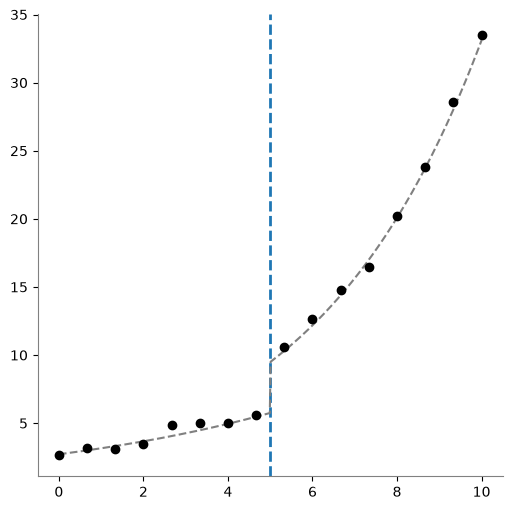

In [ ]:
# semillas
np.random.seed(12345)

# 500 números igualmente espaciados entre 0 y 10
# representando la población
x_real = np.linspace(start=0, stop=10, num=500)

# 16 valores igualmente espaciados entre 0 y 10
# representando la muestra
x_data = np.linspace(start=0, stop=10, num=16)

# valores reales de Y
d_real = f(x_real)

# valores aproximados de Y con un ruido blanco
# que se distibuye normal con meida cero
# y varianza constante
d_data = f(x_data) + np.random.normal(0, 0.4, len(x_data))

# figura de 6x6
plt.figure(figsize=(6, 6))

plt.gca().spines["left"].set_color("gray")
plt.gca().spines["bottom"].set_color("gray")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# línea en el punto 5 del eje X
plt.axvline(5, linestyle="--", color="tab:blue", linewidth=2)

# datos reales con --
plt.plot(x_real, d_real, "--", color="gray")

# datos de la muestra con 0
plt.plot(x_data, d_data, "o", color="black")
plt.show()

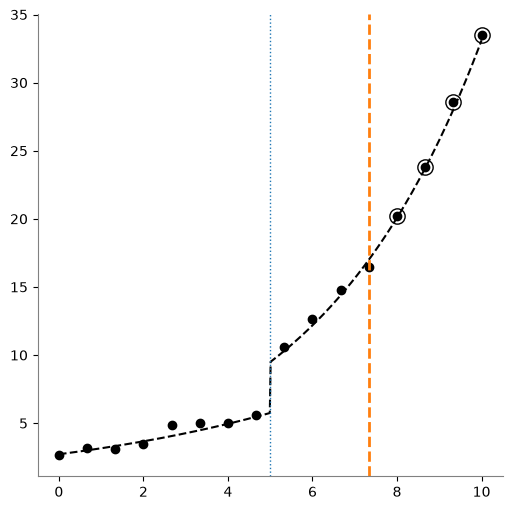

In [ ]:
# selecciona los primeros elementos del conjunto de datos
# para calibración y los 4 finales para testing
index = list(range(12))

# muestra usada para estimar los parámetros del modelo
x_fit = x_data[index]
d_fit = d_data[index]

# muestra usada para evaluar la generalización
x_test = np.delete(x_data, index)
d_test = np.delete(d_data, index)

plt.figure(figsize=(6, 6))



# datos de la muestra
plt.plot(x_data, d_data, "o", color="black")

# datos reales
plt.plot(x_real, d_real, "--", color="black")

# datos de test, circulos vacios y más grandes
plt.plot(x_test, d_test, "o", color="black", fillstyle="none", markersize=11)

# linea vertical en x = 5
plt.axvline(5, linestyle=":", color="tab:blue", linewidth=1)

# línea vertical en el 11avo valor de X
# para serparación de train contra test
plt.axvline(x_data[11], linestyle="--", color="tab:orange", linewidth=2)


# diseño
plt.gca().spines["left"].set_color("gray")
plt.gca().spines["bottom"].set_color("gray")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

## Modelo de regesión
$$y = g(x) = \exp(w_0 + w_1 x)$$

In [ ]:
def g(w0, w1, x):
    return [math.exp(w0 + w1 * xi) for xi in x]

## Función de pérdida
$$\text{SSE}(w_0, w_1) = \sum_i [d_i - g(x_i)]^2$$

In [ ]:
def SSE(w0, w1):

    y_fit = g(w0, w1, x_fit)

    # perdida en el ajuste (sesgo)
    sse_fit = sum([(di - yi) ** 2 for di, yi in zip(d_fit, y_fit)])

    # perdida en la generalización (varianza)
    y_test = g(w0, w1, x_test)
    sse_test = sum([(di - yi) ** 2 for di, yi in zip(d_test, y_test)])

    #
    # note que la función devuelve simultaneamente
    # los errores de ajuste y prueba
    #
    return sse_fit, sse_test